# 02 · Cifras de las 5V y evidencia para la arquitectura

**Proyecto:** Cloud Provider Analytics · Minería de Datos II · ISTEA 2C 2026
**Objetivo:** reproducir los números citados en las secciones 2 (5V) y 4 (arquitectura) del documento de diseño. El perfil de calidad completo está en `01_exploracion_landing.ipynb`.

In [1]:
from pathlib import Path
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

LANDING = Path('../data/datalake/landing')
EVIDENCE = Path('../evidence'); EVIDENCE.mkdir(exist_ok=True)
assert LANDING.exists(), 'Copiar el dataset en data/datalake/landing (ver data/README.md)'

files = sorted(glob.glob(str(LANDING/'usage_events_stream'/'*.jsonl')))
rows = []
for i, f in enumerate(files):
    with open(f) as fh:
        rows += [{**json.loads(l), '_file_idx': i} for l in fh]
ev = pd.DataFrame(rows)
ev['ts'] = pd.to_datetime(ev.timestamp, utc=True)
ev['value'] = pd.to_numeric(ev['value'], errors='coerce')
bytes_total = sum(Path(f).stat().st_size for f in files)
print(f'{len(files)} archivos · {len(ev):,} eventos · {bytes_total/1e6:.1f} MB')

120 archivos · 43,200 eventos · 12.9 MB


## 1. Volumen: muestra vs. escala proyectada
La proyección es un **supuesto** de un proveedor real; los parámetros se pueden ajustar.

In [2]:
bytes_evento = bytes_total / len(ev)
muestra = {'eventos/día': len(ev) / ev.ts.dt.date.nunique(), 'bytes/evento': bytes_evento,
           'orgs': ev.org_id.nunique(), 'recursos': ev.resource_id.nunique()}
print({k: round(v, 1) for k, v in muestra.items()})

RECURSOS, METRICAS, INTERVALO_MIN = 500_000, 3, 5           # supuestos de producción
ev_dia = RECURSOS * METRICAS * (24 * 60 // INTERVALO_MIN)
print(f'Proyección: {ev_dia/1e6:,.0f} M eventos/día · {ev_dia*bytes_evento/1e9:,.0f} GB/día JSON · '
      f'{ev_dia*bytes_evento*30/1e12:,.1f} TB/mes')

{'eventos/día': 720.0, 'bytes/evento': 299.2, 'orgs': 80, 'recursos': 400}
Proyección: 432 M eventos/día · 129 GB/día JSON · 3.9 TB/mes


## 2. Valor: dónde se concentra el costo

In [3]:
c = ev.cost_usd_increment
spike = c > 5 * c.quantile(.99)
genai = ev.service == 'genai'
valor = pd.Series({
    'costo total eventos (USD)': round(c.sum()),
    'costo en spikes (USD)': round(c[spike].sum()),
    '% del costo en spikes': f'{c[spike].sum()/c.sum():.1%}',
    'eventos spike': int(spike.sum()),
    '% eventos genai': f'{genai.mean():.1%}',
    '% costo genai': f'{c[genai].sum()/c.sum():.1%}',
})
valor

costo total eventos (USD)    147434
costo en spikes (USD)          9321
% del costo en spikes          6.3%
eventos spike                    49
% eventos genai                9.6%
% costo genai                 20.0%
dtype: object

In [4]:
t = pd.read_csv(LANDING/'support_tickets.csv')
pd.Series({'% tickets con SLA incumplido': f'{t.sla_breached.mean():.1%}',
           '% tickets abiertos': f'{t.resolved_at.isna().mean():.1%}',
           '% tickets high/critical': f"{t.severity.isin(['high','critical']).mean():.1%}"})

% tickets con SLA incumplido     9.5%
% tickets abiertos              24.0%
% tickets high/critical         26.0%
dtype: str

In [5]:
b = pd.read_csv(LANDING/'billing_monthly.csv')
fx = b.groupby('currency').agg(facturas=('invoice_id','size'), subtotal_mediana=('subtotal','median'),
                               tc_min=('exchange_rate_to_usd','min'), tc_max=('exchange_rate_to_usd','max'))
fx['subtotal_mediana_x_tc'] = (fx.subtotal_mediana * b.groupby('currency').exchange_rate_to_usd.median()).round(2)
fx   # ARS: subtotal de magnitud USD × 0,0016 ≈ 1 USD → inconsistencia de moneda

,facturas,subtotal_mediana,tc_min,tc_max,subtotal_mediana_x_tc
currency,,,,,
ARS,51,816.100,0.00133,0.00162,1.22
EUR,29,697.840,0.99810,1.19808,770.88
USD,160,657.605,0.85463,1.11791,654.42


## 3. Velocidad: ¿qué watermark soporta este stream?

Se simula la llegada de los 120 archivos **en orden** y, para cada archivo, el watermark de Spark = máximo `timestamp` visto en los lotes anteriores − retraso tolerado. Un evento con `timestamp` menor al watermark se descartaría en una agregación por ventana de tiempo de evento.

In [6]:
ev = ev.sort_values('_file_idx')
max_previo = ev.groupby('_file_idx').ts.max().cummax().shift(1)
base = ev._file_idx.map(max_previo)
sim = []
for d in ['2h', '1D', '7D', '30D', '60D']:
    sim.append({'retraso_tolerado': d, '% eventos descartados': round((ev.ts < base - pd.Timedelta(d)).mean() * 100, 1)})
sim = pd.DataFrame(sim); sim

,retraso_tolerado,% eventos descartados
0,2h,99.0
1,1D,97.5
2,7D,87.6
3,30D,49.6
4,60D,0.0


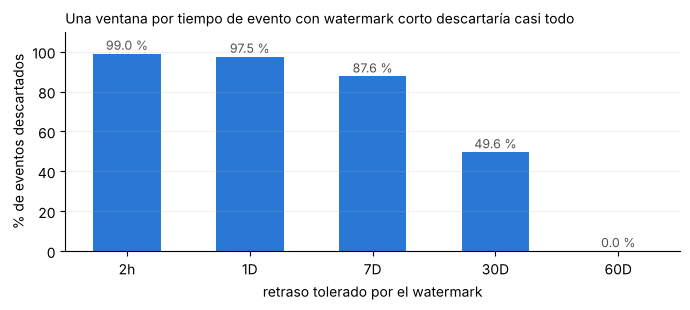

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(sim.retraso_tolerado, sim['% eventos descartados'], color='#2a78d6', width=.55)
for i, v in enumerate(sim['% eventos descartados']): ax.text(i, v + 2, f'{v:.1f} %', ha='center', fontsize=9, color='#52514e')
ax.set_ylim(0, 110); ax.set_ylabel('% de eventos descartados'); ax.set_xlabel('retraso tolerado por el watermark')
ax.set_title('Una ventana por tiempo de evento con watermark corto descartaría casi todo', loc='left', fontsize=10)
[ax.spines[k].set_visible(False) for k in ('top', 'right')]; ax.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.savefig(EVIDENCE/'simulacion_watermark.png', dpi=120); plt.show()
sim.to_csv(EVIDENCE/'simulacion_watermark.csv', index=False)

**Conclusión para la arquitectura (§4):** en este stream la llegada está completamente desordenada, así que **no** se agrega con ventanas por tiempo de evento dentro del stream. En su lugar:

1. Bronze y Silver se escriben en modo *append* sin descartar eventos tardíos.
2. El watermark se usa solo para acotar el estado de la deduplicación por `event_id`.
3. En `foreachBatch` se recalculan desde Silver las claves `(org, fecha, servicio)` que tocó el lote y se hace upsert. Así el resultado es correcto aunque el evento llegue con semanas de atraso, y reprocesar un lote no duplica nada.
4. El cierre batch D+1 recalcula el día anterior completo como control.